# Predicting Final Destination Waste Treatment Type (Ireland EPA Waste Data, 2021-2024)

## Notebook purpose
This notebook builds a **supervised classification** project to predict the **final destination waste treatment type** from EPA licensee waste data for 2021-2024.

## Notebook structure
1. Load and merge the four yearly datasets  
2. Inspect data quality and missing values  
3. Define the business problem and target classes  
4. Carry out EDA and descriptive statistics  
5. Use **Binomial**, **Poisson**, and **Normal** distributions for statistical analysis  
6. Prepare the data for machine learning  
7. Train and tune **two classification models**  
8. Compare results and interpret findings  
9. Summarise conclusions and limitations  

## Problem definition
The raw EPA treatment labels are very detailed. For a clearer academic classification task, I reduce them into five broader classes:

- `recycling_related_recovery`
- `other_recovery`
- `thermal_treatment`
- `landfill_disposal`
- `other_disposal`

## Why this problem is suitable
This is a realistic waste-management analytics problem because treatment routing is an operational decision. The dataset includes a labelled final destination, so a **supervised learning** approach is appropriate.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from math import ceil

from scipy.stats import binom, poisson, norm, probplot

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## 1. Load and merge the four yearly files

The assessment says the notebook should run from start to finish.  
To keep it self-contained, I load the four CSV files directly and merge them into one dataframe.

In [4]:
possible_base_paths = [Path("."), Path("")]

file_names = [f"EPA-Licensee-Waste-Data-{year}.csv" for year in [2021, 2022, 2023, 2024]]

base_path = None
for candidate in possible_base_paths:
    if all((candidate / name).exists() for name in file_names):
        base_path = candidate
        break

if base_path is None:
    raise FileNotFoundError(
        "CSV files were not found. Put the notebook in the same folder as the four EPA CSV files, "
        "or edit the base path in this cell."
    )

file_paths = [base_path / name for name in file_names]

for path in file_paths:
    print(path, "exists ->", path.exists())

df_list = [pd.read_csv(path, low_memory=False) for path in file_paths]
df = pd.concat(df_list, ignore_index=True)

print("Merged shape:", df.shape)
df.head()

EPA-Licensee-Waste-Data-2021.csv exists -> True
EPA-Licensee-Waste-Data-2022.csv exists -> True
EPA-Licensee-Waste-Data-2023.csv exists -> True
EPA-Licensee-Waste-Data-2024.csv exists -> True
Merged shape: (31028, 15)


,Reporting Year,Licence Profile,Waste Source,Waste Action,List of Waste Code,Low Code Description,Respondent Waste Description,Accepted Waste Quantity,Accepted waste quantity from abroad,Accepted Waste Quantity from Ireland,On Site Waste Treatment Type,Waste Quantity Tonnes per Year,Next Destination Waste Treatment Type,Final Destination Abroad,Final Destination Waste Treatment Type
0,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 01,paper and cardboard packaging,Cardboard,40.58,0.0,40.58,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN
1,2021,Ashgrove Recycling - W0147,Accepted,Transferred,15 01 01,paper and cardboard packaging,Cardboard,NaN,NaN,NaN,NaN,97.88,R13 - Storage of waste pending any of the oper...,NaN,NaN
2,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 02,plastic packaging,plastic packaging,0.06,0.0,0.06,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN
3,2021,Ashgrove Recycling - W0147,Accepted,Transferred,15 01 02,plastic packaging,Plastic Packaging,NaN,NaN,NaN,NaN,7.64,R13 - Storage of waste pending any of the oper...,NaN,NaN
4,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 03,wooden packaging,wooden packaging,0.26,0.0,0.26,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN


## 2. First look at the data

This quick inspection helps confirm:
- column names
- data types
- whether the merge worked correctly

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31028 entries, 0 to 31027
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Reporting Year                          31028 non-null  int64  
 1   Licence Profile                         31028 non-null  object 
 2   Waste Source                            31028 non-null  object 
 3   Waste Action                            31028 non-null  object 
 4   List of Waste Code                      31028 non-null  object 
 5   Low Code Description                    31028 non-null  object 
 6   Respondent Waste Description            30667 non-null  object 
 7   Accepted Waste Quantity                 12939 non-null  float64
 8   Accepted waste quantity from abroad     12939 non-null  float64
 9   Accepted Waste Quantity from Ireland    12939 non-null  float64
 10  On Site Waste Treatment Type            13837 non-null  ob

In [7]:
df.sample(5, random_state=42)

,Reporting Year,Licence Profile,Waste Source,Waste Action,List of Waste Code,Low Code Description,Respondent Waste Description,Accepted Waste Quantity,Accepted waste quantity from abroad,Accepted Waste Quantity from Ireland,On Site Waste Treatment Type,Waste Quantity Tonnes per Year,Next Destination Waste Treatment Type,Final Destination Abroad,Final Destination Waste Treatment Type
8193,2022,Bord Na Móna Recycling Limited - W0104,Waste Accepted,Waste Accepted,20 03 01 B,Municipal mixed residual non-household,Commercial Mixed Municipal Waste,5556.62,0.0,5556.62,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN
29959,2024,Starrus Eco Holdings Limited (Littleton) - W0249,Waste Accepted,Waste Accepted,20 01 25,edible oil and fat,Grease trap waste,7.66,0.0,7.66,R03 - Composting (aerobic),NaN,NaN,NaN,NaN
30541,2024,The Hammond Lane Metal Company Limited - P0997,Accepted,Transferred,17 04 02,Aluminium,Aluminium,NaN,NaN,NaN,NaN,25.480,NaN,Yes,R04 - Preparing for reuse of metal and metal c...
20769,2023,Rilta Environmental - W0185,Accepted,Transferred,06 02 04*,sodium and potassium hydroxide,Caustic soda,NaN,NaN,NaN,NaN,13.582,NaN,No,"D09 - Physico-chemical treatment, not specifie..."
4813,2021,Padraig Thornton Waste Disposal Limited - P1014,Accepted,Transferred,19 12 12,other wastes (including mixtures of materials)...,other wastes from mechanical treatment of wastes,NaN,NaN,NaN,NaN,5.320,NaN,No,R01 - Co-incineration plant (use as fuel) - no...


## 3. Missing values and data quality

The raw dataset contains many empty values.  
This is important because some columns are **structurally empty** for particular waste actions.

For example:
- accepted-waste columns are mostly empty for transferred rows
- final destination fields are empty for many non-transferred rows
- on-site treatment is relevant for waste treated on site, not for every row

So, instead of globally imputing the whole raw dataset, I first inspect missingness and then define a modelling subset.

In [9]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_summary = missing_percent.reset_index()
missing_summary.columns = ["Column", "Missing %"]
missing_summary

,Column,Missing %
0,Next Destination Waste Treatment Type,82.32
1,Final Destination Waste Treatment Type,59.59
2,Accepted Waste Quantity,58.30
3,Accepted waste quantity from abroad,58.30
4,Accepted Waste Quantity from Ireland,58.30
5,Final Destination Abroad,57.25
6,On Site Waste Treatment Type,55.40
7,Waste Quantity Tonnes per Year,41.70
8,Respondent Waste Description,1.16
9,Reporting Year,0.00


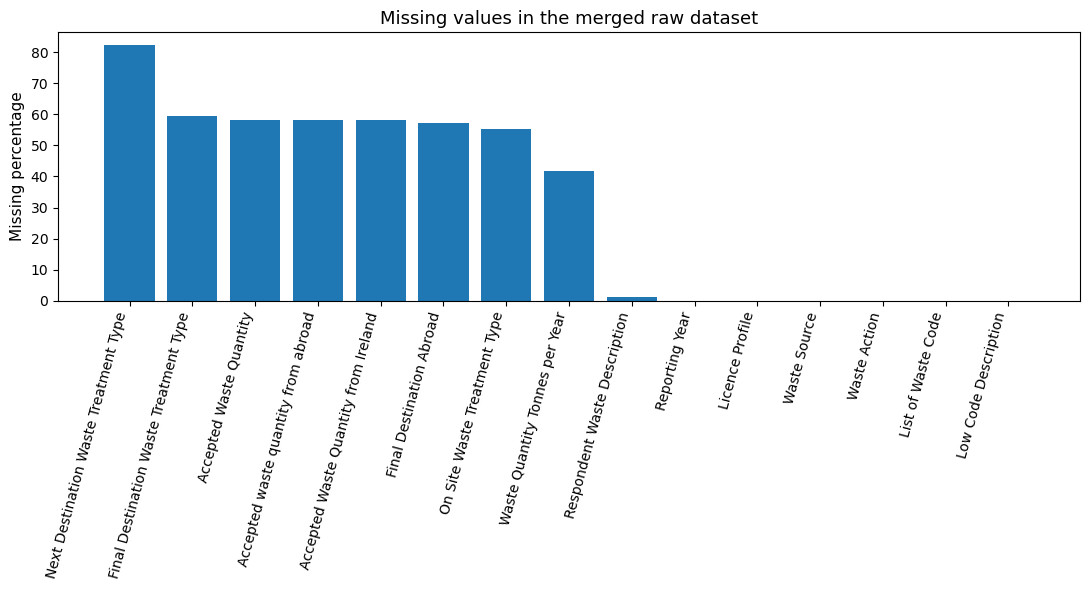

In [10]:
plt.figure(figsize=(11, 6))
plt.bar(missing_summary["Column"], missing_summary["Missing %"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing percentage")
plt.title("Missing values in the merged raw dataset")
plt.tight_layout()
plt.show()

### Short comment on missing values
The chart should show that several columns have very high missingness.  
This is one reason why the modelling task should be narrowed to a relevant subset instead of using every row and every column.

## 4. Define the modelling subset

### Why use only transferred rows with a known final destination?
The target variable is **Final Destination Waste Treatment Type**.  
That field is only meaningful when the waste has actually been transferred and a final destination has been recorded.

So I keep only:
- `Waste Action == 'Transferred'`
- rows where `Final Destination Waste Treatment Type` is not missing

This gives a cleaner and more defensible supervised learning problem.

In [13]:
model_df = df[
    (df["Waste Action"] == "Transferred") &
    (df["Final Destination Waste Treatment Type"].notna())
].copy()

print("Modelling subset shape:", model_df.shape)

(model_df.isna().mean() * 100).sort_values(ascending=False).round(2)

Modelling subset shape: (12537, 15)


Accepted Waste Quantity                   100.00
Accepted waste quantity from abroad       100.00
Accepted Waste Quantity from Ireland      100.00
On Site Waste Treatment Type              100.00
Next Destination Waste Treatment Type      93.34
Respondent Waste Description                0.92
Reporting Year                              0.00
Licence Profile                             0.00
Waste Source                                0.00
Waste Action                                0.00
List of Waste Code                          0.00
Low Code Description                        0.00
Waste Quantity Tonnes per Year              0.00
Final Destination Abroad                    0.00
Final Destination Waste Treatment Type      0.00
dtype: float64

## 5. Simple cleaning and target creation

### Cleaning choices
I keep the code simple:
- strip spaces from text fields
- convert text placeholders such as `na` to real missing values
- create a few simple engineered features
- group EPA treatment labels into broader classes

### Why group the raw treatment labels?
The raw target has many detailed codes. Grouping them into broader operational classes:
- makes the classification task clearer
- reduces extreme fragmentation
- gives more interpretable results

In [15]:
text_cols = [
    "Licence Profile",
    "List of Waste Code",
    "Low Code Description",
    "Respondent Waste Description",
    "Next Destination Waste Treatment Type",
    "Final Destination Abroad",
    "Final Destination Waste Treatment Type"
]

for col in text_cols:
    model_df[col] = model_df[col].astype(str).str.strip()

model_df["Respondent Waste Description"] = model_df["Respondent Waste Description"].replace(
    {"na": np.nan, "nan": np.nan, "NaN": np.nan, "NA": np.nan, "<NA>": np.nan}
)

model_df["waste_code_chapter"] = model_df["List of Waste Code"].str.split().str[0]
model_df["next_dest_code"] = model_df["Next Destination Waste Treatment Type"].str.extract(r"(^[A-Z0-9]+)")

In [16]:
def map_treatment_group(value):
    if pd.isna(value):
        return np.nan

    value = str(value).upper()
    code = value.split(" - ")[0]

    # recycling / reuse / reclamation
    if code in ["R02", "R03", "R04", "R05", "R06", "R07", "R08", "R09", "RU"]:
        return "recycling_related_recovery"

    # thermal treatment / energy recovery / incineration
    elif code == "R01" or "INCINERATION" in value or "CO-INCINERATION" in value:
        return "thermal_treatment"

    # landfill-like disposal
    elif code in ["D01", "D05"]:
        return "landfill_disposal"

    # other disposal routes
    elif code.startswith("D"):
        return "other_disposal"

    # remaining recovery routes such as R10, R11, R12, R13
    else:
        return "other_recovery"

model_df["target"] = model_df["Final Destination Waste Treatment Type"].apply(map_treatment_group)

model_df[["Final Destination Waste Treatment Type", "target"]].head(10)

,Final Destination Waste Treatment Type,target
7,R11 - Use of waste obtained from any of the op...,other_recovery
10,R05 - Preparing for reuse of inorganic materials,recycling_related_recovery
15,R01 - Incineration plant (use as fuel) - non-h...,thermal_treatment
17,R13 - Storage of waste pending any of the oper...,other_recovery
19,R13 - Storage of waste pending any of the oper...,other_recovery
29,R10 - Land treatment resulting in benefit to a...,other_recovery
30,R10 - Land treatment resulting in benefit to a...,other_recovery
32,R10 - Land treatment resulting in benefit to a...,other_recovery
34,R13 - Storage of waste pending any of the oper...,other_recovery
35,R13 - Storage of waste pending any of the oper...,other_recovery


## 6. Target distribution

Before building models, I check the class balance.  
This matters because the classes are not perfectly balanced, so **F1-score** will be more informative than accuracy alone.

In [18]:
target_counts = model_df["target"].value_counts().sort_values(ascending=False)
target_counts

target
recycling_related_recovery    5096
other_recovery                3878
thermal_treatment             2274
landfill_disposal              771
other_disposal                 518
Name: count, dtype: int64

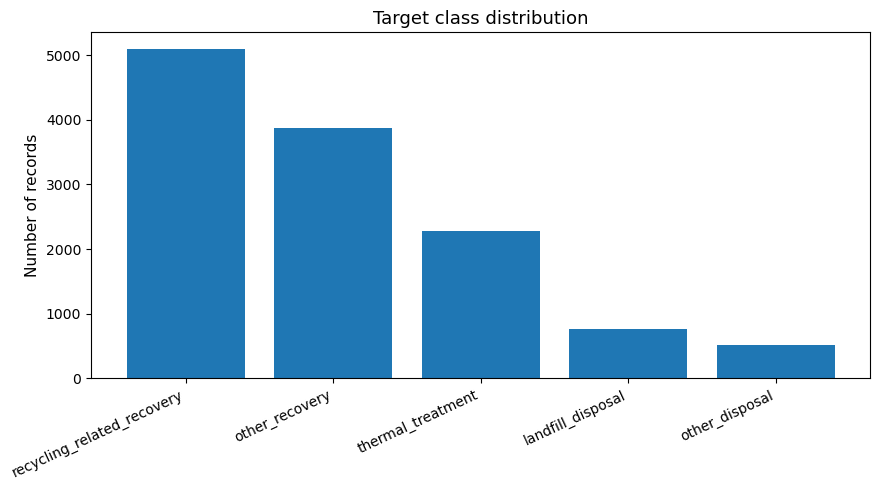

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(target_counts.index, target_counts.values)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of records")
plt.title("Target class distribution")
plt.tight_layout()
plt.show()

## 7. Descriptive statistics

The main continuous variable available for transferred waste is `Waste Quantity Tonnes per Year`.  
I summarise it overall and by target class.

In [21]:
quantity_summary = model_df["Waste Quantity Tonnes per Year"].describe().to_frame().T
quantity_summary

,count,mean,std,min,25%,50%,75%,max
Waste Quantity Tonnes per Year,12537.0,1121.102938,5843.816868,0.0,5.778,46.901,290.92,402520.0


In [22]:
group_quantity_summary = model_df.groupby("target")["Waste Quantity Tonnes per Year"].describe().round(2)
group_quantity_summary

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
landfill_disposal,771.0,2947.87,15698.78,0.3,79.35,508.28,1843.92,402520.00
other_disposal,518.0,1296.49,6162.68,0.0,2.46,14.88,82.05,55359.02
other_recovery,3878.0,560.00,2562.76,0.0,3.54,45.35,247.27,43917.46
recycling_related_recovery,5096.0,881.89,3951.15,0.0,11.77,53.14,276.88,117696.70
thermal_treatment,2274.0,1954.75,6893.64,0.0,2.26,17.34,185.38,90241.16


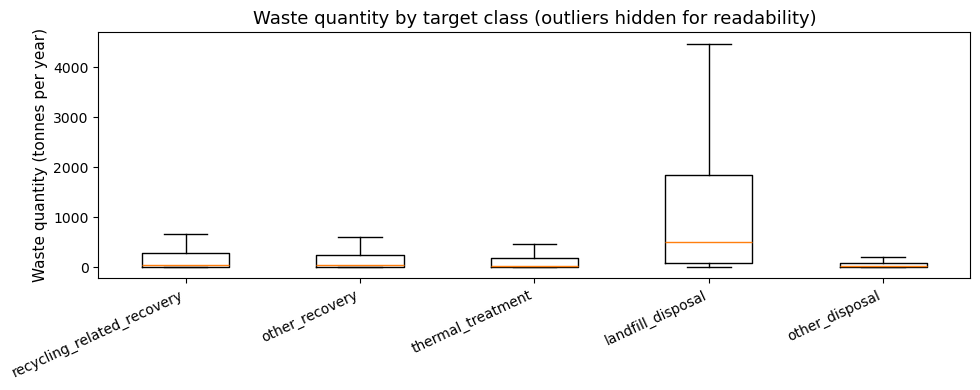

In [23]:
plt.figure(figsize=(10, 4))
plt.boxplot(
    [model_df.loc[model_df["target"] == c, "Waste Quantity Tonnes per Year"] for c in target_counts.index],
    labels=target_counts.index,
    showfliers=False
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Waste quantity (tonnes per year)")
plt.title("Waste quantity by target class (outliers hidden for readability)")
plt.tight_layout()
plt.show()

### Interpretation
The waste quantity variable is highly right-skewed.  
That means:
- the **mean** is much larger than the **median**
- a few very large movements strongly affect the average
- for normal-based analysis, a transformation is more appropriate

## 8. Waste treatment pattern by year

A stacked proportional chart is useful here because it shows whether treatment routing changed over time.

In [26]:
year_target_prop = pd.crosstab(
    model_df["Reporting Year"],
    model_df["target"],
    normalize="index"
)

year_target_prop

target,landfill_disposal,other_disposal,other_recovery,recycling_related_recovery,thermal_treatment
Reporting Year,,,,,
2021,0.079854,0.034791,0.374089,0.341617,0.169649
2022,0.054573,0.042988,0.339329,0.387500,0.175610
2023,0.054698,0.041828,0.322394,0.393179,0.187902
2024,0.057809,0.045353,0.202491,0.502076,0.192271


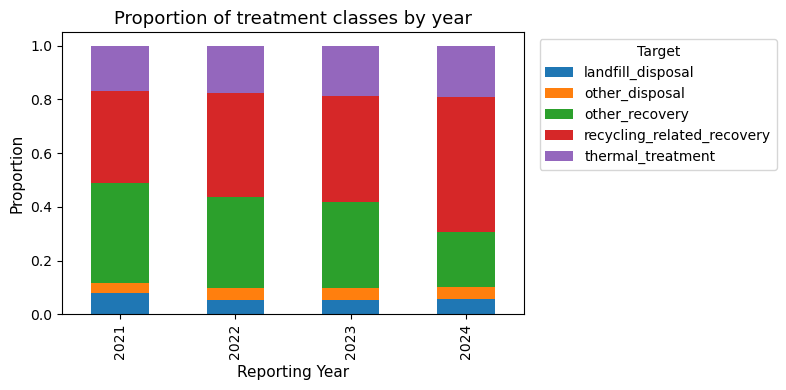

In [27]:
year_target_prop.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("Proportion")
plt.title("Proportion of treatment classes by year")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. EDA comments and Tufte principles

The visual design follows simple **Tufte-inspired** principles:
- avoid chartjunk
- no 3D effects
- use clear axis labels and titles
- keep the focus on the data, not decoration
- use consistent scales where possible
- hide extreme outliers in the boxplot when needed so the main data pattern is visible

This improves readability and makes the graphics more suitable for analytical reporting.

# 10. Statistical analysis

The brief requires:
- descriptive statistics and plots
- **Binomial** and **Poisson** distributions
- **Normal** distribution
- explanation of why these distributions matter

I use:
1. **Binomial** for whether waste goes abroad (`Yes/No`)  
2. **Poisson** for number of transferred records per licence-year  
3. **Normal** for the **log-transformed** waste quantity

## 10.1 Binomial distribution

### Why Binomial is appropriate
`Final Destination Abroad` is a binary variable with two outcomes:
- Yes
- No

So, if I take a sample of `n` transferred records, the number sent abroad can be modelled with a Binomial distribution.

I estimate `p` from the data, then visualise the Binomial distribution for a sample of 100 records.

In [31]:
abroad_yes = (model_df["Final Destination Abroad"] == "Yes").sum()
abroad_total = model_df["Final Destination Abroad"].notna().sum()
p_hat = abroad_yes / abroad_total

print("Estimated probability of being sent abroad (p̂):", round(p_hat, 4))
print("Yes count:", abroad_yes)
print("Total count:", abroad_total)

Estimated probability of being sent abroad (p̂): 0.5404
Yes count: 6775
Total count: 12537


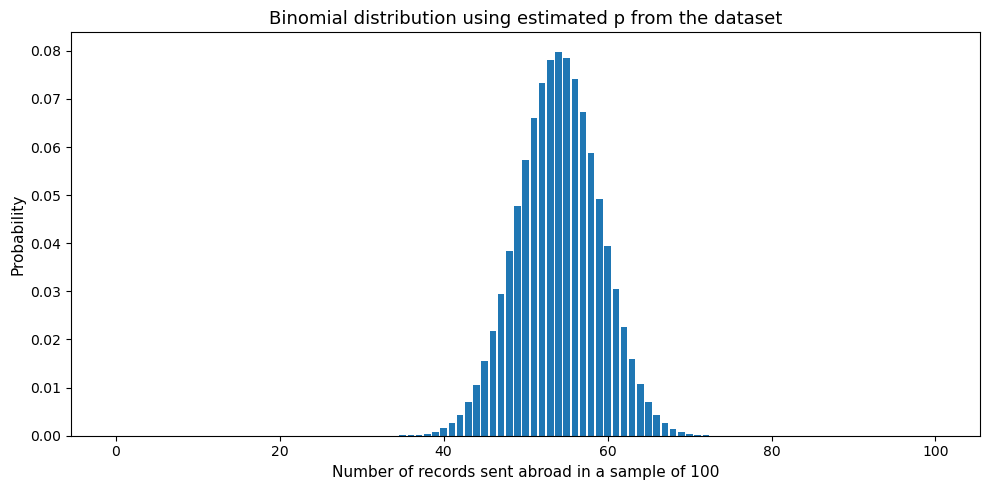

In [32]:
n_binom = 100
x_binom = np.arange(0, n_binom + 1)
binom_pmf = binom.pmf(x_binom, n=n_binom, p=p_hat)

plt.figure(figsize=(10, 5))
plt.bar(x_binom, binom_pmf)
plt.xlabel("Number of records sent abroad in a sample of 100")
plt.ylabel("Probability")
plt.title("Binomial distribution using estimated p from the dataset")
plt.tight_layout()
plt.show()

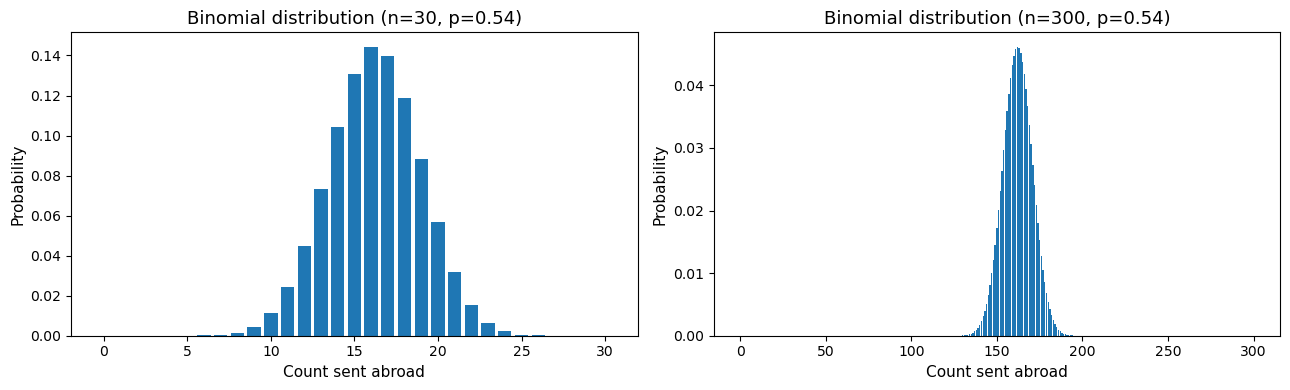

In [33]:
# Large-sample behaviour: Binomial becomes more bell-shaped as n gets large
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, n_value in zip(axes, [30, 300]):
    x = np.arange(0, n_value + 1)
    pmf = binom.pmf(x, n=n_value, p=p_hat)
    ax.bar(x, pmf)
    ax.set_title(f"Binomial distribution (n={n_value}, p={p_hat:.2f})")
    ax.set_xlabel("Count sent abroad")
    ax.set_ylabel("Probability")

plt.tight_layout()
plt.show()

### Binomial interpretation
This distribution is useful because it models a **binary operational outcome**.  
With larger sample sizes, the Binomial shape becomes more symmetric and begins to resemble a Normal distribution.  
That is one reason large-sample proportion methods often use Normal approximations.

## 10.2 Poisson distribution

### Why Poisson is appropriate
Poisson is used for **count data over a fixed interval**.

Here I use:
- **number of transferred records per licence per year**

This is a count of events in a fixed time unit (one year), so Poisson is a reasonable starting point.

In [36]:
licence_year_counts = model_df.groupby(["Reporting Year", "Licence Profile"]).size()
lambda_hat = licence_year_counts.mean()

print("Estimated lambda (mean count per licence-year):", round(lambda_hat, 3))
print("Variance of counts:", round(licence_year_counts.var(), 3))
licence_year_counts.describe().round(2)

Estimated lambda (mean count per licence-year): 25.327
Variance of counts: 1735.646


count    495.00
mean      25.33
std       41.66
min        1.00
25%        5.00
50%       13.00
75%       23.50
max      273.00
dtype: float64

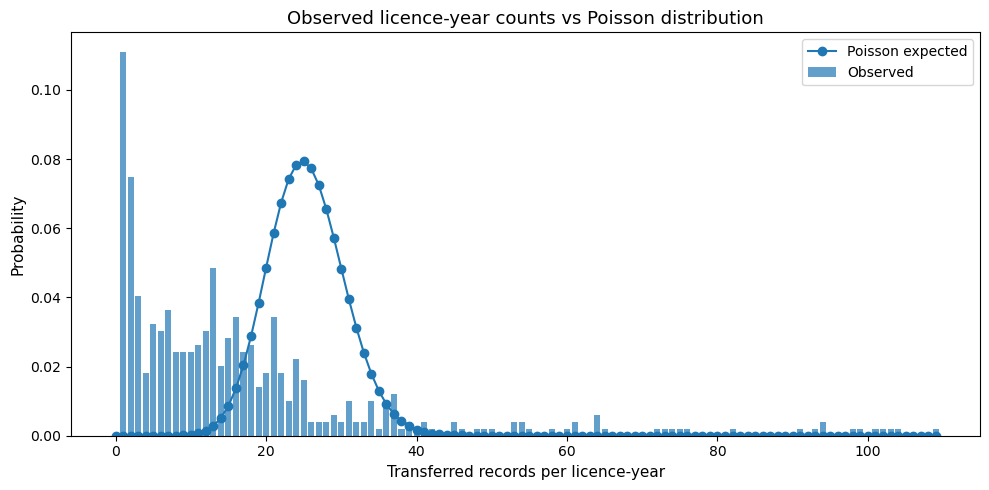

In [37]:
max_count_to_plot = int(np.percentile(licence_year_counts, 95))
observed_counts = licence_year_counts.value_counts().sort_index()
x_pois = np.arange(0, max_count_to_plot + 1)

observed_prob = observed_counts.reindex(x_pois, fill_value=0) / len(licence_year_counts)
poisson_prob = poisson.pmf(x_pois, mu=lambda_hat)

plt.figure(figsize=(10, 5))
plt.bar(x_pois, observed_prob, alpha=0.7, label="Observed")
plt.plot(x_pois, poisson_prob, marker="o", label="Poisson expected")
plt.xlabel("Transferred records per licence-year")
plt.ylabel("Probability")
plt.title("Observed licence-year counts vs Poisson distribution")
plt.legend()
plt.tight_layout()
plt.show()

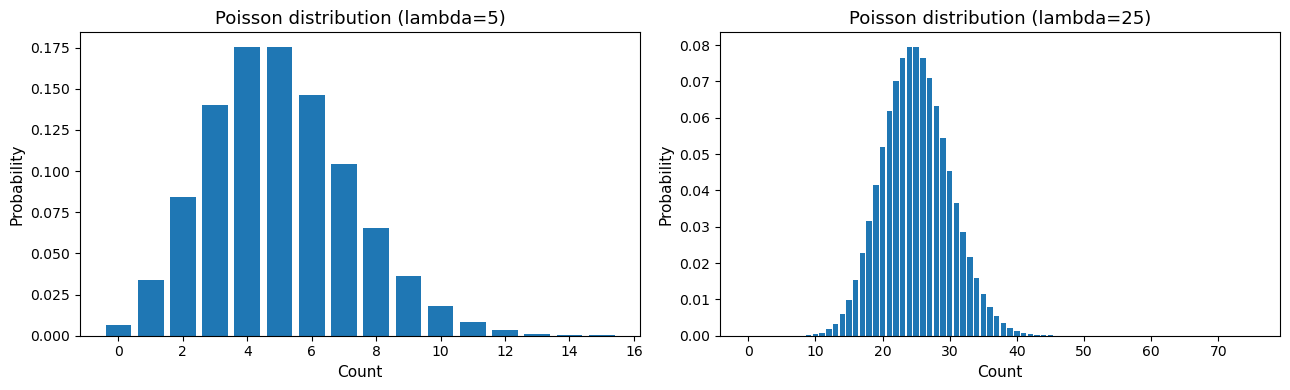

In [38]:
# Large-sample behaviour: larger lambda gives a more bell-shaped Poisson distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, lambda_value in zip(axes, [5, round(lambda_hat)]):
    x = np.arange(0, int(lambda_value * 3) + 1)
    pmf = poisson.pmf(x, mu=lambda_value)
    ax.bar(x, pmf)
    ax.set_title(f"Poisson distribution (lambda={lambda_value})")
    ax.set_xlabel("Count")
    ax.set_ylabel("Probability")

plt.tight_layout()
plt.show()

### Poisson interpretation
Poisson gives a useful reference model for counts, but the data should also be criticised.  
If the variance is much larger than the mean, the data are **over-dispersed**, which suggests that a simple Poisson model is not perfect.

That is actually a good academic finding:
- Poisson helps explain the count structure
- but the licence-year counts are influenced by site heterogeneity, so the fit is imperfect

## 10.3 Normal distribution

### Why I use a transformed variable
`Waste Quantity Tonnes per Year` is strongly right-skewed, so the raw variable is not close to Normal.

A common and simple fix is:
- `log1p(quantity)` = `log(1 + quantity)`

This reduces skewness and makes a Normal-based interpretation more reasonable.

In [41]:
model_df["log_quantity"] = np.log1p(model_df["Waste Quantity Tonnes per Year"])

print("Raw quantity mean:", round(model_df["Waste Quantity Tonnes per Year"].mean(), 2))
print("Raw quantity median:", round(model_df["Waste Quantity Tonnes per Year"].median(), 2))
print("Log quantity mean:", round(model_df["log_quantity"].mean(), 3))
print("Log quantity std:", round(model_df["log_quantity"].std(), 3))

Raw quantity mean: 1121.1
Raw quantity median: 46.9
Log quantity mean: 3.965
Log quantity std: 2.527


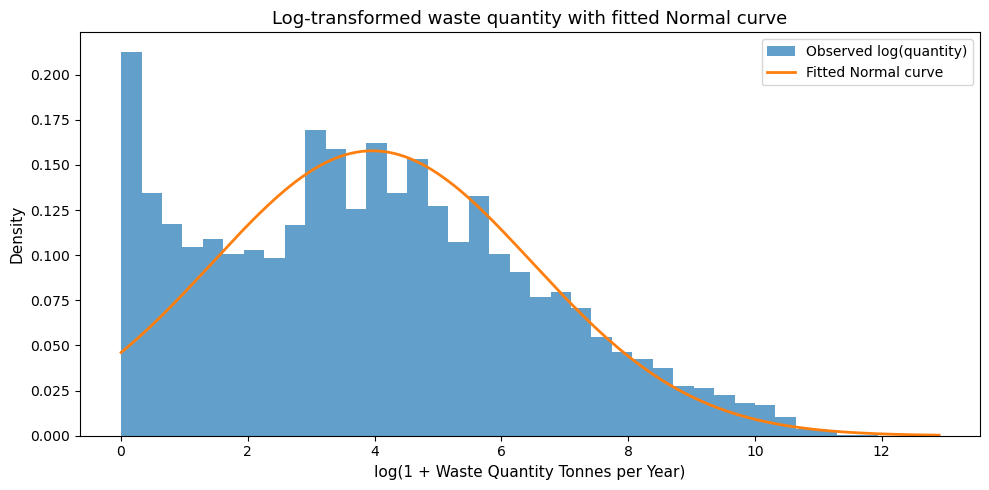

In [42]:
x = np.linspace(model_df["log_quantity"].min(), model_df["log_quantity"].max(), 300)
mu = model_df["log_quantity"].mean()
sigma = model_df["log_quantity"].std()

plt.figure(figsize=(10, 5))
plt.hist(model_df["log_quantity"], bins=40, density=True, alpha=0.7, label="Observed log(quantity)")
plt.plot(x, norm.pdf(x, loc=mu, scale=sigma), linewidth=2, label="Fitted Normal curve")
plt.xlabel("log(1 + Waste Quantity Tonnes per Year)")
plt.ylabel("Density")
plt.title("Log-transformed waste quantity with fitted Normal curve")
plt.legend()
plt.tight_layout()
plt.show()

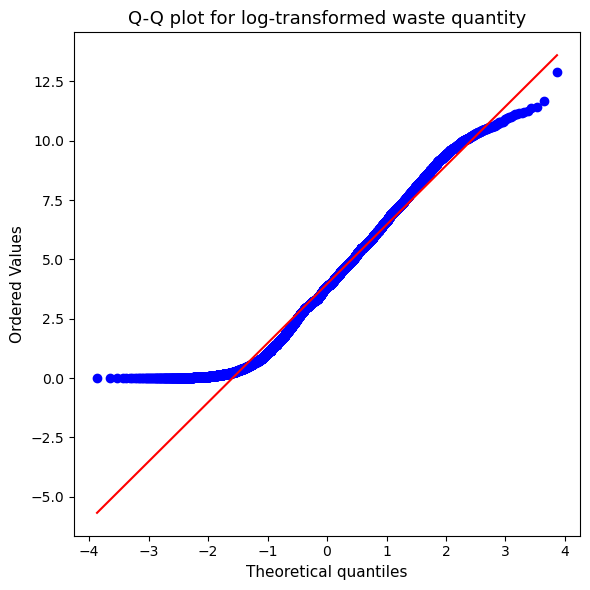

In [43]:
plt.figure(figsize=(6, 6))
probplot(model_df["log_quantity"], dist="norm", plot=plt)
plt.title("Q-Q plot for log-transformed waste quantity")
plt.tight_layout()
plt.show()

In [44]:
within_1sd = (
    model_df["log_quantity"].between(mu - sigma, mu + sigma).mean()
)

within_2sd = (
    model_df["log_quantity"].between(mu - 2 * sigma, mu + 2 * sigma).mean()
)

print("Proportion within 1 standard deviation:", round(within_1sd, 3))
print("Proportion within 2 standard deviations:", round(within_2sd, 3))

Proportion within 1 standard deviation: 0.63
Proportion within 2 standard deviations: 0.966


### Normal interpretation
The transformed variable is much more suitable for Normal-style reasoning than the raw variable.

This matters because:
- Normal-based summaries and z-score interpretation become more meaningful
- many modelling ideas assume at least approximate symmetry

### Could the Binomial and Poisson variables be treated as Normal?
Not directly at the record level:
- `Final Destination Abroad` is binary, so Binomial is the correct natural model
- `licence_year_counts` are integer counts, so Poisson is the natural count model

However, with **large samples**, both Binomial and Poisson can be approximated by the Normal distribution under suitable conditions.

# 11. Project framework and machine learning strategy

## Why CRISP-DM is suitable
I select **CRISP-DM** because it matches the structure of a real data analytics project:

1. **Business understanding**  
   Predict the final waste treatment class

2. **Data understanding**  
   Inspect missing values, class balance, variable meaning

3. **Data preparation**  
   Clean strings, handle missing values, engineer simple features

4. **Modelling**  
   Train and tune classification models

5. **Evaluation**  
   Compare metrics and interpret model suitability

6. **Deployment**  
   In a real project, the model could support treatment planning or reporting

CRISP-DM is stronger here than a purely modelling-focused framework because this project needs clear justification of business problem, data preparation and interpretation.

## Why supervised learning is the correct choice
The dataset contains a known label:
- `Final Destination Waste Treatment Type`

After grouping it into broader classes, I have a labelled target, so this is clearly a **supervised classification** problem.

# 12. Data preparation for machine learning

## Preparation decisions
To keep the notebook simple and robust, I use the following features:

- `Reporting Year`
- `Licence Profile`
- `List of Waste Code`
- `Low Code Description`
- `Final Destination Abroad`
- `Waste Quantity Tonnes per Year`
- `Next Destination Waste Treatment Type`
- `waste_code_chapter`
- `next_dest_code`

## Why not use every available column?
Some columns are unusable for this modelling subset because they are completely empty here:
- accepted quantity fields
- on-site treatment field

I also leave out `Respondent Waste Description` because it is noisy free text with many inconsistent spellings and would add complexity without guaranteed benefit.

## Preprocessing choices
- **Median imputation** for numeric features  
- **Most-frequent imputation** for categorical features  
- **StandardScaler** for numeric features  
- **OneHotEncoder** for categorical features  

These are standard and appropriate choices for mixed tabular data.

In [49]:
# Drop columns that are completely empty inside the modelling subset
empty_cols_in_model = model_df.columns[model_df.isna().all()].tolist()
empty_cols_in_model

['Accepted Waste Quantity',
 'Accepted waste quantity from abroad',
 'Accepted Waste Quantity from Ireland',
 'On Site Waste Treatment Type']

In [50]:
feature_cols = [
    "Reporting Year",
    "Licence Profile",
    "List of Waste Code",
    "Low Code Description",
    "Final Destination Abroad",
    "Waste Quantity Tonnes per Year",
    "Next Destination Waste Treatment Type",
    "waste_code_chapter",
    "next_dest_code"
]

X = model_df[feature_cols].copy()
y = model_df["target"].copy()

numeric_features = ["Reporting Year", "Waste Quantity Tonnes per Year"]
categorical_features = [col for col in feature_cols if col not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10029, 9)
X_test shape: (2508, 9)


In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Reporting Year',
                                  'Waste Quantity Tonnes per Year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Licence Profile', 'List of Waste Code',
                                  'Low Code Description',
                                  'Final Destination Abroad',
                                  'Next Destination Waste Treatment Type',
                                  'waste_code_chapter', 'next_dest_code'])])

# 13. Build and tune two models

The brief asks for at least two machine learning models and hyperparameter tuning.

I compare:
1. **Logistic Regression**  
   A strong, interpretable baseline for multi-class classification

2. **Random Forest**  
   A flexible tree-based model that can capture non-linear relationships

I use **GridSearchCV** with small grids to keep the notebook simple and fast enough to run comfortably.

In [53]:
models_and_parameters = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "model__C": [0.1, 1]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "params": {
            "model__n_estimators": [120],
            "model__max_depth": [None, 20],
            "model__min_samples_split": [2, 5]
        }
    }
}

In [54]:
search_results = {}
comparison_rows = []

for model_name, config in models_and_parameters.items():
    print("=" * 70)
    print("Training:", model_name)

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring="f1_micro",
        cv=3,
        n_jobs=1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    predictions = best_model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average="micro")

    search_results[model_name] = {
        "grid": grid,
        "best_model": best_model,
        "predictions": predictions
    }

    comparison_rows.append({
        "Model": model_name,
        "Best Parameters": grid.best_params_,
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4)
    })

results_df = pd.DataFrame(comparison_rows).sort_values("F1 Score", ascending=False)
results_df

Training: Logistic Regression
Training: Random Forest


,Model,Best Parameters,Accuracy,F1 Score
1,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.8365,0.8365
0,Logistic Regression,{'model__C': 1},0.7978,0.7978


## Why I compare F1 score as well as Accuracy
Accuracy can look strong even when minority classes are predicted poorly.  
Because the target classes are somewhat imbalanced, **F1** is the fairest main comparison metric here.

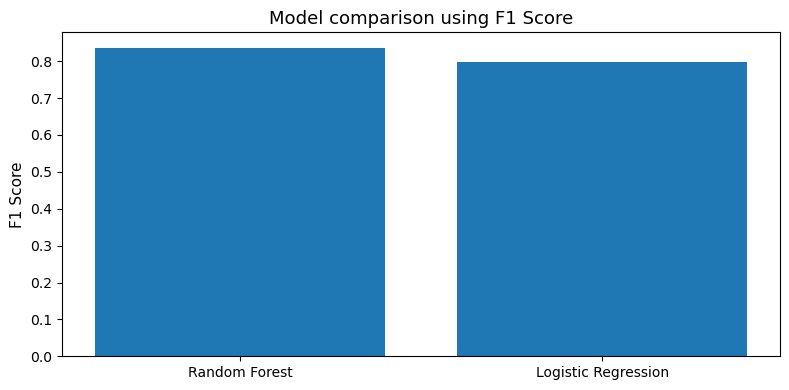

In [56]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.ylabel("F1 Score")
plt.title("Model comparison using F1 Score")
plt.tight_layout()
plt.show()

## 14. Detailed model evaluation

In [58]:
best_model_name = results_df.iloc[0]["Model"]
best_model = search_results[best_model_name]["best_model"]

print("Best model:", best_model_name)
print()
print(classification_report(y_test, search_results[best_model_name]["predictions"]))

Best model: Random Forest

                            precision    recall  f1-score   support

         landfill_disposal       0.70      0.58      0.63       154
            other_disposal       0.72      0.56      0.63       104
            other_recovery       0.89      0.84      0.87       776
recycling_related_recovery       0.86      0.91      0.88      1019
         thermal_treatment       0.75      0.82      0.78       455

                  accuracy                           0.84      2508
                 macro avg       0.79      0.74      0.76      2508
              weighted avg       0.84      0.84      0.83      2508



<Figure size 600x500 with 0 Axes>

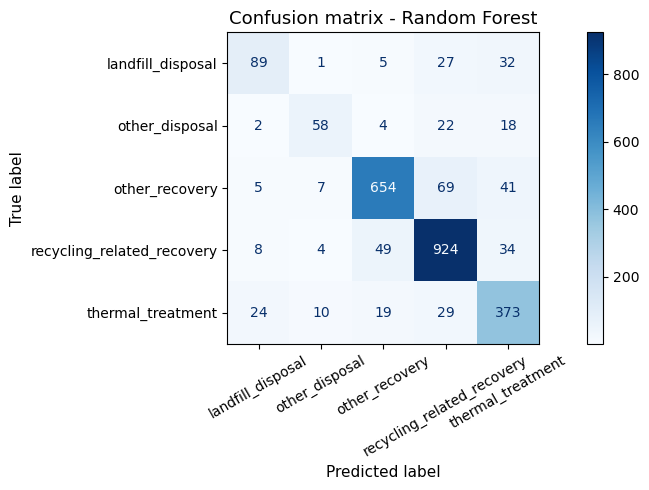

<Figure size 600x500 with 0 Axes>

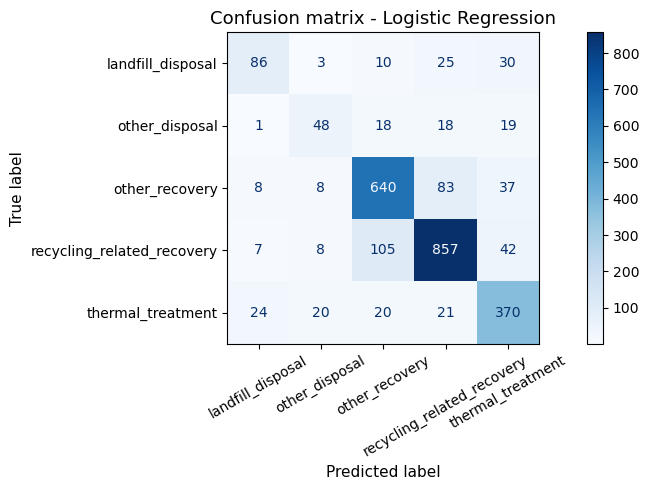

In [59]:
for model_name in results_df["Model"]:
    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(
        search_results[model_name]["best_model"],
        X_test,
        y_test,
        xticks_rotation=30,
        cmap="Blues"
    )
    plt.title(f"Confusion matrix - {model_name}")
    plt.tight_layout()
    plt.show()

# 15. Interpretation of the machine learning results

## Similarities
Both models use the same training/test split, same features and same preprocessing, so the comparison is fair.

## Differences
- **Logistic Regression** is simpler and gives a strong baseline
- **Random Forest** can capture more complex patterns and may perform better when feature relationships are non-linear

## Practical interpretation
If the Random Forest performs better on F1 Score, that suggests the routing decision depends on more complex combinations of waste code, destination information, licence profile and quantity.

If the Logistic Regression performs nearly as well, that is useful too, because simpler models are easier to explain.

## Metric choice
F1 score is especially important because it checks whether smaller classes such as disposal-related categories are also being predicted reasonably well.

# 16. Final conclusions

## Main findings
- The raw merged dataset contains many missing values, but many are **structural**, not accidental
- A clean modelling task can be created by focusing on **transferred waste rows with a known final destination**
- Grouping the detailed EPA treatment labels into five broader classes gives a practical multi-class classification problem
- The data show clear class imbalance, so **F1 score** is a useful evaluation metric
- The quantity variable is strongly skewed, so a log transform is helpful for Normal-based analysis
- Binomial and Poisson distributions are both useful, but they must also be criticised:
  - Binomial suits the abroad/not-abroad outcome
  - Poisson suits count data, but the counts appear over-dispersed
- CRISP-DM is an appropriate framework because the project requires business understanding, data preparation, modelling and evaluation

## Limitations
- The target grouping is a simplification of detailed EPA treatment categories
- The dataset is record-based and may not capture all operational context
- Free-text waste descriptions are noisy and were left out to keep the notebook simple and robust

## Possible future improvement
A later version could:
- clean and standardise the respondent description field more fully
- test gradient boosting models
- use class weights or resampling if minority-class performance needs to improve